In [1]:
from __future__ import annotations

import operator
from typing import TypedDict, List, Annotated

from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage

from dotenv import load_dotenv
load_dotenv()
llm = ChatOpenAI()

In [2]:

class Task(BaseModel):
    id: int
    title: str
    brief: str = Field(..., description="What to cover")

In [3]:

class Plan(BaseModel):
    blog_title: str
    tasks: List[Task]

In [4]:
class State(TypedDict):
    topic: str
    plan: Plan
    # reducer: results from workers get concatenated automatically
    sections: Annotated[List[str], operator.add]
    final: str

In [5]:

llm = ChatOpenAI(model="gpt-4.1-mini")

In [6]:

def orchestrator(state: State) -> dict:

    plan = llm.with_structured_output(Plan).invoke(
        [
            SystemMessage(
                content=(
                    "Create a blog plan with 5-7 sections on the following topic."
                )
            ),
            HumanMessage(content=f"Topic: {state['topic']}"),
        ]
    )
    return {"plan": plan}

In [7]:

def fanout(state: State):
    return [Send("worker", {"task": task, "topic": state["topic"], "plan": state["plan"]})
            for task in state["plan"].tasks]

In [8]:

def worker(payload: dict) -> dict:

    # payload contains what we sent
    task = payload["task"]
    topic = payload["topic"]
    plan = payload["plan"]

    blog_title = plan.blog_title

    section_md = llm.invoke(
        [
            SystemMessage(content="Write one clean Markdown section."),
            HumanMessage(
                content=(
                    f"Blog: {blog_title}\n"
                    f"Topic: {topic}\n\n"
                    f"Section: {task.title}\n"
                    f"Brief: {task.brief}\n\n"
                    "Return only the section content in Markdown."
                )
            ),
        ]
    ).content.strip()

    return {"sections": [section_md]}

In [9]:
from pathlib import Path

In [10]:
from pathlib import Path

def reducer(state: State) -> dict:
    
    title = state["plan"].blog_title
    body = "\n\n".join(state["sections"]).strip()

    final_md = f"# {title}\n\n{body}\n"

    # ---- save to file ----
    filename = title.lower().replace(" ", "_") + ".md"
    output_path = Path(filename)
    output_path.write_text(final_md, encoding="utf-8")

    return {"final": final_md}

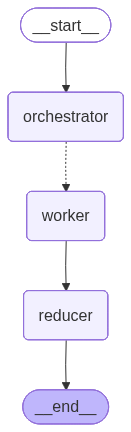

In [11]:

g = StateGraph(State)
g.add_node("orchestrator", orchestrator)
g.add_node("worker", worker)
g.add_node("reducer", reducer)


g.add_edge(START, "orchestrator")
g.add_conditional_edges("orchestrator", fanout, ["worker"])
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

app = g.compile()

app

In [12]:
app.invoke({"topic": "Write a blog on Self Attention", "sections": []})

{'topic': 'Write a blog on Self Attention',
 'plan': Plan(blog_title='Understanding Self-Attention: The Backbone of Modern Neural Networks', tasks=[Task(id=1, title='Introduction to Self-Attention', brief='Explain the concept of self-attention, its origin, and why it is important in machine learning and natural language processing.'), Task(id=2, title='The Mechanics of Self-Attention', brief='Describe how self-attention works, including key, query, value vectors, and the attention score calculation.'), Task(id=3, title='Self-Attention vs. Traditional Attention Mechanisms', brief='Compare self-attention with traditional attention to highlight its unique features and advantages.'), Task(id=4, title='Applications of Self-Attention', brief='Discuss key applications such as Transformers, BERT, GPT models, and their reliance on self-attention.'), Task(id=5, title='Benefits and Challenges of Self-Attention', brief='Outline the benefits like parallelization and ability to capture long-range de

In [13]:
app.invoke({"topic": "Write a blog on Transformer: Encoder Decoder", "sections": []})

{'topic': 'Write a blog on Transformer: Encoder Decoder',
 'plan': Plan(blog_title='Understanding Transformers: The Encoder-Decoder Architecture', tasks=[Task(id=1, title='Introduction to Transformers', brief='Provide an overview of the Transformer model, its significance in deep learning, and why the encoder-decoder architecture is important.'), Task(id=2, title='The Encoder Component', brief='Explain the structure and functioning of the encoder, including self-attention mechanisms and how input sequences are processed.'), Task(id=3, title='The Decoder Component', brief='Describe the decoder structure, its use of masked self-attention, and how it generates output sequences based on encoder representations.'), Task(id=4, title='How Encoder and Decoder Work Together', brief='Illustrate how the encoder and decoder interact during training and inference, highlighting the flow of information and attention between them.'), Task(id=5, title='Applications of the Encoder-Decoder Transformer', 